In [4]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import matplotlib.ticker as ticker
import seaborn as sns

from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent, GreedyAgent
from ant.decentralised.special_strategies import EgalitarianAgent, PettyAgent, ImitationAgent, SatisficingAgent
from ant.centralised import P4

In [5]:
market_size = 20
simulation_length = 1200
num_repeats = 30

pure_strategies = {
    # "Proportional": ProportionalAgent,
    "Greedy": GreedyAgent,
    "Egalitarian": EgalitarianAgent,
    # "Petty": PettyAgent,
    # "Imitation": ImitationAgent,
    # "Satisficing": SatisficingAgent
}

# Create all unique 1-to-1 mixtures (e.g. ('Greedy', 'Egalitarian'))
strategy_pairs = list(itertools.combinations(pure_strategies.keys(), 2))
graph_types = ["complete", "random", "grid", "scale-free", "small-world"]

# Dictionary to store all simulation results across the repeats
all_results = {f"{p1}_vs_{p2}": {gtype: [] for gtype in graph_types} for p1, p2 in strategy_pairs}

In [6]:
for repeat in range(num_repeats):
    print(f"Running repeat {repeat + 1}/{num_repeats}...")
    current_seed = 657849724 + repeat
    
    # 1. Generate the Networks ensuring connectivity where required
    rnd_seed = current_seed
    random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    while not nx.is_connected(random_graph):
        rnd_seed += 1000  
        random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    
    graphs = {
        "complete": nx.complete_graph(market_size),
        "random": random_graph,
        "grid" : nx.convert_node_labels_to_integers(nx.grid_2d_graph(int(market_size / 4), 4)),
        "scale-free" : nx.barabasi_albert_graph(market_size, 1, seed=current_seed),
        "small-world": nx.connected_watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=current_seed),
    }

    half_size = market_size // 2

    for graph_type, graph in graphs.items():
        for p1, p2 in strategy_pairs:
            ClassA = pure_strategies[p1]
            ClassB = pure_strategies[p2]
            
            # 2. Build 1-to-1 mixed agent array
            mixed_agents = []
            for i in range(0, half_size):
                mixed_agents.append(ClassA(id=i, seed=current_seed + i))
            for i in range(half_size, market_size):
                mixed_agents.append(ClassB(id=i, seed=current_seed + i))
                
            # 3. Create Market 
            _market = Market(
                market_size, graph=graph, agents=mixed_agents, seed=current_seed, agent_type=BaseAgent
            )
            
            # Reattach market and initialize properties properly for mixed agents
            for agent in _market.agents:
                agent.market = _market
                agent.received = np.zeros(market_size, dtype=float)
                agent.received_history = np.zeros((10000, market_size), dtype=float)

            # 4. Centralized calculation & Simulation Setup
            optimal_aloc, utility_vec = P4(_market)
            _market.set_market_equilibrium(optimal_aloc, utility_vec)
            
            simulated_state = _market.simulate(simulation_length)
            all_results[f"{p1}_vs_{p2}"][graph_type].append(simulated_state)

Running repeat 1/30...
Running repeat 2/30...
Running repeat 3/30...
Running repeat 4/30...
Running repeat 5/30...
Running repeat 6/30...
Running repeat 7/30...
Running repeat 8/30...
Running repeat 9/30...
Running repeat 10/30...
Running repeat 11/30...
Running repeat 12/30...
Running repeat 13/30...
Running repeat 14/30...
Running repeat 15/30...
Running repeat 16/30...
Running repeat 17/30...
Running repeat 18/30...
Running repeat 19/30...
Running repeat 20/30...
Running repeat 21/30...
Running repeat 22/30...
Running repeat 23/30...
Running repeat 24/30...
Running repeat 25/30...
Running repeat 26/30...
Running repeat 27/30...
Running repeat 28/30...
Running repeat 29/30...
Running repeat 30/30...


In [14]:
training_period = 0
time_steps = np.arange(training_period, simulation_length)

FULL_WIDTH = 3.5
HALF_WIDTH = 1.6

PALETTE = [
    "#66c2a5",
    "#fc8d62",
    "#8da0cb",
    "#e78ac3",
    "#a6d854",
    "#ffd92f",
    "#e5c494",
    "#b3b3b3",

]

MARKERS = ["o", "D", "^", "s", "v", "x"]

DASHES = [
    (),          # solid
    (5, 2),      # dashed
    (2, 2),      # dotted
    (7, 2, 2, 2), # dash-dot
    (5, 2, 2, 2, 2, 2),  # dash-dot-dot
    (1, 1),      # dense dot
]

sns.set_theme(
    style="white",
    palette=PALETTE,
    rc = {
    # Figure
    "figure.figsize":        (5.5, 3.5),
    "figure.dpi":            150,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
    "savefig.pad_inches":    0.05,
    "figure.facecolor":      "white",
    "axes.facecolor":        "white",
 
    # Font — use a serif family for body text similarity; switch to
    # "sans-serif" if your paper uses a sans body font (e.g. ACM 2023).
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif", "Palatino"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
 
    # Axes
    "axes.linewidth":        0.6,
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.prop_cycle":       plt.cycler(color=PALETTE),
 
    # Grid — subtle horizontal lines only
    "axes.grid":             True,
    "axes.grid.axis":        "y",
    "grid.color":            "#cccccc",
    "grid.linewidth":        0.4,
    "grid.linestyle":        "--",
 
    # Ticks
    "xtick.direction":       "out",
    "ytick.direction":       "out",
    "xtick.major.width":     0.6,
    "ytick.major.width":     0.6,
    "xtick.major.size":      3.0,
    "ytick.major.size":      3.0,
    "xtick.minor.visible":   False,
    "ytick.minor.visible":   False,
 
    # Lines & markers
    "lines.linewidth":       1.4,
    "lines.markersize":      5,
    "lines.markeredgewidth": 0.8,
 
    # Legend
    "legend.frameon":        True,
    "legend.framealpha":     0.9,
    "legend.edgecolor":      "#cccccc",
    "legend.borderpad":      0.4,
    "legend.labelspacing":   0.3,
    "legend.handlelength":   2.0,
 
    # Error bars
    "errorbar.capsize":      3,
 
    # PDF/SVG vector output — embed fonts for camera-ready submissions
    "pdf.fonttype":          42,   # TrueType (not Type 3)
    "ps.fonttype":           42,
    "svg.fonttype":          "none",
}

)

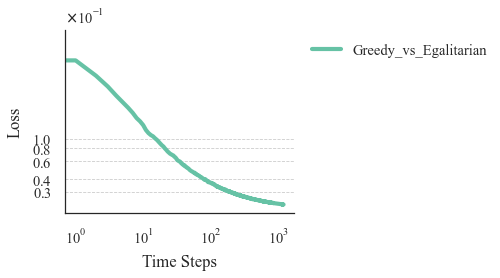

In [15]:
rows = []
for pair_name in all_results.keys():
    for graph_type in graph_types:
        for repeat_id, series in enumerate(all_results[pair_name][graph_type]):
            series = np.asarray(series)
            for t in range(training_period, len(series)):
                rows.append(
                    {
                        "strategy": pair_name,
                        "graph_type": graph_type,
                        "repeat": repeat_id,
                        "timestep": t,
                        "loss": series[t],
                    }
                )

df = pd.DataFrame(rows)

# 1) Aggregate over all graph types and repeats
# plt.figure(figsize=(FULL_WIDTH, 2.4))
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 2.))
sns.lineplot(
    data=df,
    x="timestep",
    y="loss",
    hue="strategy",
    estimator="mean",
    errorbar=None,
    linewidth=2,
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_yticks([0.10,0.03, 0.04, 0.06, 0.08])
ax.set_yticklabels(["0.10","0.030", "0.040", "0.060", "0.080"])

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
# plt.savefig("figs/vs/aggregate.pdf")
plt.show()